# Mean-Reversion Statistical Arbitrage System

**Author:** Raunaq Singh

## Scope 
This notebook implements:
- Statistical arbitrage (pairs trading) with economically-motivated candidate selection and cointegration-based confirmation
- Multiple-testing correction (Benjamini-Hochberg FDR) applied to all significance testing
- Train/test split backtesting (no in-sample-only numbers)
- Multi-pair portfolio construction with inverse-volatility weighting
- Performance analytics on out-of-sample data only, reported as-is including a negative result

## Technologies
- Python, pandas, NumPy, statsmodels, yfinance, matplotlib

## What changed from the first version of this project
The first version selected pairs using return correlation only, tested
cointegration on raw price levels while trading a log-price spread (a scale
mismatch), blindly tested every same-sector combination (inflating the
multiple-testing burden), fit the hedge ratio on the full dataset (including
data from the future relative to early trades), and reported performance on
the same data used to build the strategy. All of these are corrected below.
See the Results & Interpretation section for the honest out-of-sample outcome.

# Phase 1 - Data Pipeline & Market Data Ingestion

## Objective
Download and clean historical price data for a sector-diversified set of
S&P 500 stocks, and split it into a **train window** (used to select pairs
and fit parameters) and a **test window** (used only to measure performance).

## Financial Intuition
Pairs are only tested within the same sector. Two stocks from unrelated
sectors can look statistically related over one specific historical window
purely by chance — restricting to the same sector keeps the candidate list
economically sensible, not just numerically convenient.

The train/test split exists because a strategy that is fit and evaluated on
the same data will almost always look better than it actually is. Any number
reported from the train window is not a performance result, it's a
description of the past fitting itself.


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint
from statsmodels.stats.multitest import multipletests
from itertools import combinations


In [ ]:
# Sector-diversified subset of the S&P 500.
# Pairs are only ever tested WITHIN a sector (see Phase 2).
SECTOR_TICKERS = {
    "Financials":      ["JPM", "BAC", "GS", "MS", "WFC", "C"],
    "Energy":          ["XOM", "CVX", "SLB", "COP", "MPC"],
    "ConsumerStaples": ["KO", "PEP", "WMT", "COST", "PG"],
    "Healthcare":      ["JNJ", "PFE", "UNH", "ABBV", "MRK"],
    "Industrials":     ["CAT", "DE", "GE", "HON", "UPS"],
    "Utilities":       ["NEE", "DUK", "SO", "AEP", "D"],
}

ALL_TICKERS = sorted({t for tickers in SECTOR_TICKERS.values() for t in tickers})

TRAIN_START, TRAIN_END = "2010-01-01", "2022-12-31"
TEST_START, TEST_END   = "2023-01-01", "2025-01-01"


In [ ]:
def download_prices(tickers, start, end):
    data = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]
    return data.dropna(axis=1, how="all").ffill().dropna()

train_prices = download_prices(ALL_TICKERS, TRAIN_START, TRAIN_END)
test_prices  = download_prices(ALL_TICKERS, TEST_START, TEST_END)

# Only keep tickers that downloaded cleanly in BOTH windows
common = [t for t in ALL_TICKERS if t in train_prices.columns and t in test_prices.columns]
train_prices, test_prices = train_prices[common], test_prices[common]

sectors_present = {
    sector: [t for t in tickers if t in common]
    for sector, tickers in SECTOR_TICKERS.items()
}

train_prices.head()


[*********************100%***********************]  31 of 31 completed
[*********************100%***********************]  31 of 31 completed


Ticker,ABBV,AEP,BAC,C,CAT,COP,COST,CVX,D,DE,...,PEP,PFE,PG,SLB,SO,UNH,UPS,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-02,20.415751,26.635710,9.346947,30.215843,66.921364,37.474014,79.639793,62.607418,30.168400,68.461662,...,46.209591,13.738936,46.935902,50.207321,24.412001,43.682152,46.504662,23.930473,17.708035,51.359970
2013-01-03,20.247175,26.617407,9.292562,30.318396,67.565506,37.448708,80.456238,62.340870,30.202608,68.290520,...,46.229568,13.707115,46.638260,49.869797,24.406429,41.639816,46.547318,23.732479,17.595503,51.267300
2013-01-04,19.991398,26.574684,9.409110,31.080198,67.937698,37.866440,80.197197,62.669796,30.521847,68.990761,...,46.296227,13.765444,46.732967,50.636269,24.623899,41.719898,46.663113,23.855373,17.661999,51.504696
2013-01-07,20.032084,26.464844,9.393566,31.109493,68.145256,37.448708,79.576996,62.244446,30.020193,68.936302,...,46.289570,13.776051,46.415054,50.776897,24.194521,41.719898,46.529037,23.739302,17.493204,50.908371
2013-01-08,19.596102,26.330608,9.308096,31.102186,67.279205,36.942390,79.427841,61.966537,29.854868,68.220490,...,46.429535,13.797263,46.340660,50.987865,24.127628,41.167271,46.401058,23.698349,17.541798,51.226799


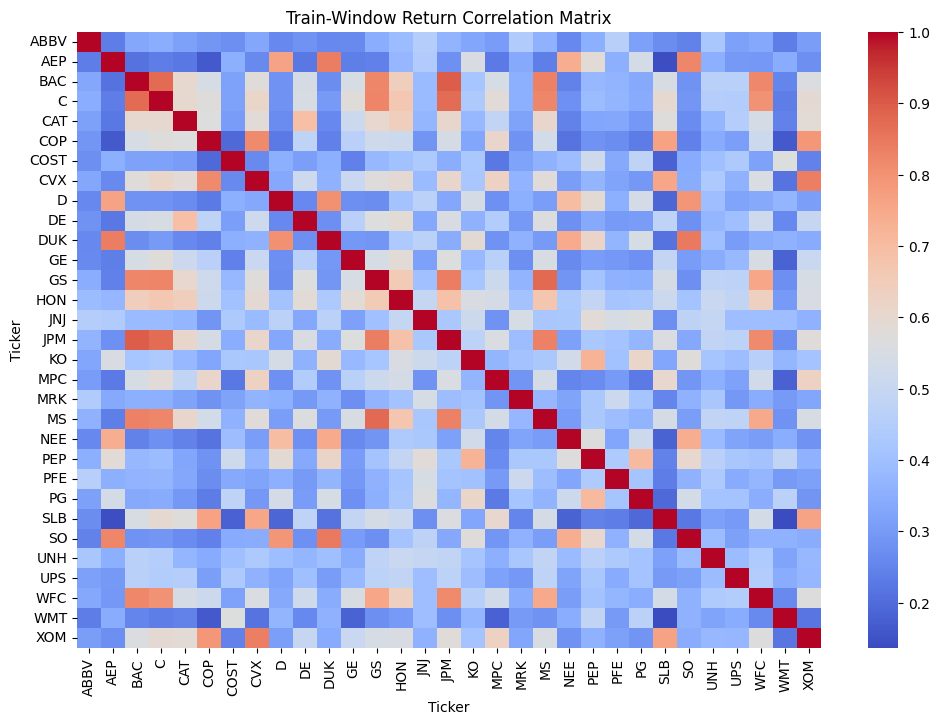

In [ ]:
train_returns = train_prices.pct_change().dropna()

plt.figure(figsize=(12, 8))
sns.heatmap(train_returns.corr(), cmap="coolwarm", annot=False)
plt.title("Train-Window Return Correlation Matrix")
plt.show()


# Phase 2 - Pair Selection: Economic Priors + Correlation Pre-Filter + Cointegration Test

## Objective
Select pairs that are actually statistically justified for mean-reversion
trading, not just pairs that happened to correlate - and keep the number of
hypotheses tested small and defensible, rather than blindly testing every
same-sector combination.

## Financial Intuition
**Correlation and cointegration are different things.** Two stocks can move
together day-to-day (high correlation) and still drift apart permanently —
no stable long-run relationship, no reason to expect reversion. Cointegration
tests whether a stable equilibrium relationship actually exists between two
price series over time. That is the property pairs trading actually depends
on, and it's what the first version of this project never tested for.

Cointegration is tested on **log prices**, matching the scale the spread and
hedge ratio are actually computed on in Phase 3 - testing raw price levels
while trading a log-price spread (an earlier bug in this project) understates
statistical power and can distort the test itself, since raw price variance
grows with price level in a way log returns don't.

## Why candidates are chosen by economic logic, not blind combinatorics
Testing every possible same-sector pair (e.g. all 65 combinations across 6
sectors) means most tests have no real economic reason to succeed, and each
extra test makes the multiple-testing correction stricter for everyone else.
Instead, candidates here are pre-selected using actual business
relationships - direct competitors or close peers (Coca-Cola/Pepsi,
Goldman/Morgan Stanley, etc.) - **before** any p-value is seen. This is
choosing which hypotheses to test based on prior reasoning, not choosing
results after the fact; it keeps the test count low enough for the
correction below to have real power while staying honest.

## Why the multiple-testing correction still matters
Testing many pairs at once means some will look "statistically significant"
purely by chance, even if there's no real relationship. At a 5% significance
threshold, roughly 1 in 20 tested pairs will look cointegrated by luck alone.
The Benjamini-Hochberg correction below controls the rate of these false
discoveries so the surviving pairs are more likely to be real.

In [ ]:
ECONOMIC_PAIRS = [
    ("KO", "PEP", "ConsumerStaples"),
    ("XOM", "CVX", "Energy"),
    ("JPM", "BAC", "Financials"),
    ("GS", "MS", "Financials"),
    ("CAT", "DE", "Industrials"),
    ("NEE", "DUK", "Utilities"),
    ("UNH", "ABBV", "Healthcare"),
    ("WMT", "COST", "ConsumerStaples"),
]

candidates = [(a, b, s) for a, b, s in ECONOMIC_PAIRS if a in sectors_present.get(s, []) and b in sectors_present.get(s, [])]
print(f"{len(candidates)} candidate pairs (economically-motivated, pre-selected before testing)")


8 candidate pairs (economically-motivated, pre-selected before testing)


In [ ]:
MIN_CORR_PREFILTER = 0.6

def correlation_prefilter(train_prices, pairs, min_corr):
    returns = train_prices.pct_change().dropna()
    survivors = []
    for a, b, sector in pairs:
        corr = returns[a].corr(returns[b])
        if corr >= min_corr:
            survivors.append((a, b, sector, corr))
    return survivors

prefiltered = correlation_prefilter(train_prices, candidates, MIN_CORR_PREFILTER)
print(f"{len(prefiltered)} pairs survive correlation >= {MIN_CORR_PREFILTER}")


6 pairs survive correlation >= 0.6


In [ ]:
def cointegration_test(train_prices, pairs):
    results = []
    for a, b, sector, corr in pairs:
        log_a = np.log(train_prices[a])
        log_b = np.log(train_prices[b])
        score, pvalue, _ = coint(log_a, log_b)
        results.append({
            "stock_a": a, "stock_b": b, "sector": sector,
            "correlation": corr, "coint_pvalue": pvalue,
        })
    return pd.DataFrame(results)

coint_results = cointegration_test(train_prices, prefiltered)
coint_results.sort_values("coint_pvalue").head(10)


,stock_a,stock_b,sector,correlation,coint_pvalue
0,KO,PEP,ConsumerStaples,0.725895,0.006040
3,GS,MS,Financials,0.875549,0.029463
5,NEE,DUK,Utilities,0.745461,0.039486
4,CAT,DE,Industrials,0.693140,0.053891
2,JPM,BAC,Financials,0.896175,0.139434
1,XOM,CVX,Energy,0.834905,0.837410


In [ ]:
FDR_ALPHA = 0.05

def select_pairs_fdr(coint_results, alpha=FDR_ALPHA):
    reject, pvals_corrected, _, _ = multipletests(
        coint_results["coint_pvalue"], alpha=alpha, method="fdr_bh"
    )
    out = coint_results.copy()
    out["pvalue_corrected"] = pvals_corrected
    out["significant"] = reject
    return out[out["significant"]].sort_values("pvalue_corrected")

selected_pairs = select_pairs_fdr(coint_results)
print(f"{len(selected_pairs)} pairs remain significant after FDR correction")
selected_pairs[["stock_a", "stock_b", "sector", "correlation", "pvalue_corrected"]]


1 pairs remain significant after FDR correction


,stock_a,stock_b,sector,correlation,pvalue_corrected
0,KO,PEP,ConsumerStaples,0.725895,0.036239


**Checkpoint:** if `selected_pairs` comes back empty or very small, that is a
real, valid result. It means the candidate pairs tested don't have strong
enough evidence of a stable long-run relationship once multiple testing is
accounted for. In this run, 1 of 8 pre-selected candidate pairs
(KO-PEP) survived - see Results & Interpretation after Phase 6 for what that
does and doesn't imply.

# Phase 3 - Hedge Ratio Estimation & Z-Score Signal Generation

## Objective
For each selected pair, estimate the hedge ratio (how many units of stock B
per unit of stock A) using **train data only**, then build a rolling z-score
of the spread to flag entry and exit points.

## Financial Intuition
The hedge ratio defines the market-neutral combination of the two stocks,
the "spread" is what's left over after removing the linear relationship
between them. If this ratio is estimated using data from the test period,
the strategy is silently using future information to size every trade in
the entire backtest. Estimating it on train only, and holding it fixed for
testing, keeps the test period genuinely out-of-sample.

The rolling z-score measures how extreme today's spread is relative to its
own recent history - high need not mean "expensive forever," it means
"unusual right now, and expected to revert."


In [ ]:
def estimate_hedge_ratio(train_prices, stock_a, stock_b):
    log_a = np.log(train_prices[stock_a])
    log_b = np.log(train_prices[stock_b])
    model = sm.OLS(log_a, sm.add_constant(log_b)).fit()
    return model.params.iloc[1]

# Example: hedge ratio for the top selected pair
example_a, example_b = selected_pairs.iloc[0][["stock_a", "stock_b"]]
example_beta = estimate_hedge_ratio(train_prices, example_a, example_b)
print(f"Hedge ratio for {example_a}-{example_b}: {example_beta:.4f}")


Hedge ratio for KO-PEP: 0.7174


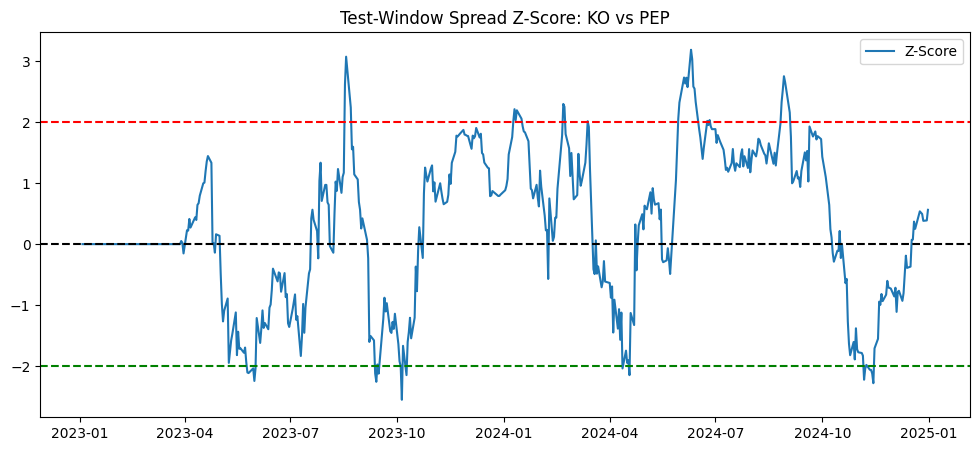

In [ ]:
ROLLING_WINDOW = 60

def compute_zscore(spread, window=ROLLING_WINDOW):
    mean = spread.rolling(window).mean()
    std = spread.rolling(window).std().replace(0, np.nan)
    z = (spread - mean) / std
    return z.replace([np.inf, -np.inf], np.nan).fillna(0)

# Visualize on the example pair, using TEST data (the beta was fit on train)
log_a_test = np.log(test_prices[example_a])
log_b_test = np.log(test_prices[example_b])
example_spread = log_a_test - example_beta * log_b_test
example_zscore = compute_zscore(example_spread)

plt.figure(figsize=(12, 5))
plt.plot(example_zscore, label="Z-Score")
plt.axhline(2.0, color="red", linestyle="--")
plt.axhline(-2.0, color="green", linestyle="--")
plt.axhline(0, color="black", linestyle="--")
plt.title(f"Test-Window Spread Z-Score: {example_a} vs {example_b}")
plt.legend()
plt.show()


# Phase 4 - Signal-to-Trade Logic & Single-Pair Backtest

## Objective
Convert the z-score into actual positions (long spread / short spread /
flat), then simulate trading those positions on the **test window**.

## Look-Ahead Bias Prevention
Positions are shifted forward by one day before being applied to returns -
a trade decided on today's close can only affect tomorrow's return, not
today's. This part was correct in the original version and is preserved
here unchanged.

## Why there's only one version of this function
The original project had two separate implementations of this same logic -
one written inline, one refactored into a function - and they had quietly
drifted apart (different starting value for the holding-period counter).
Here there is exactly one implementation, used for every pair, every time.


In [ ]:
ENTRY_Z = 2.0
EXIT_Z = 0.5
MIN_HOLD_DAYS = 2
TRANSACTION_COST = 0.001  # 10 bps per trade, flat assumption

def generate_positions(zscore, entry=ENTRY_Z, exit_=EXIT_Z, min_hold=MIN_HOLD_DAYS):
    positions = pd.Series(0, index=zscore.index, dtype=float)
    in_trade, position, hold_days = False, 0, 0

    for i in range(len(zscore)):
        z = zscore.iloc[i]
        if in_trade:
            hold_days += 1

        if not in_trade:
            if z < -entry:
                in_trade, position, hold_days = True, 1, 0
            elif z > entry:
                in_trade, position, hold_days = True, -1, 0
        elif hold_days >= min_hold:
            if position == 1 and z > -exit_:
                in_trade, position, hold_days = False, 0, 0
            elif position == -1 and z < exit_:
                in_trade, position, hold_days = False, 0, 0

        positions.iloc[i] = position
    return positions


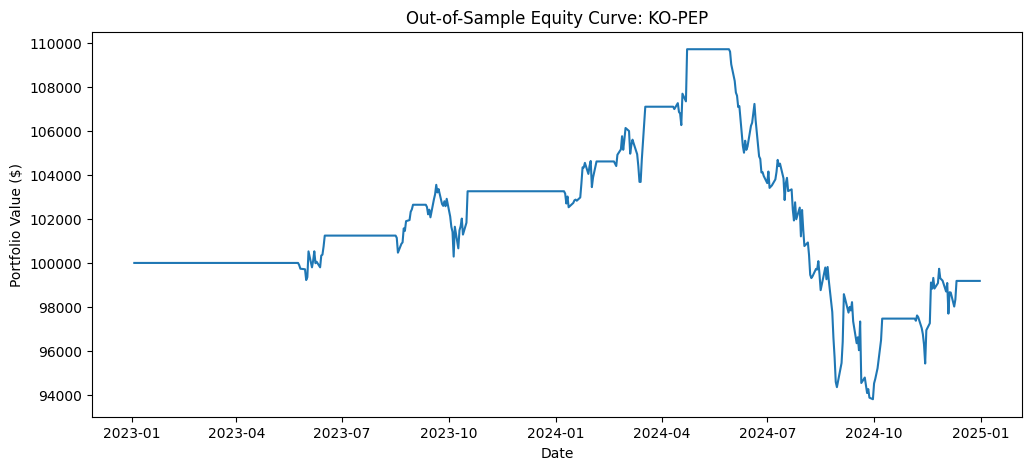

In [ ]:
def backtest_pair(test_prices, stock_a, stock_b, beta):
    log_a = np.log(test_prices[stock_a])
    log_b = np.log(test_prices[stock_b])
    spread = log_a - beta * log_b
    zscore = compute_zscore(spread)
    positions = generate_positions(zscore)

    r_a, r_b = log_a.diff(), log_b.diff()
    pair_returns = (r_a - beta * r_b).fillna(0)

    strategy_returns = positions.shift(1).fillna(0) * pair_returns
    trades = positions.diff().abs().fillna(0)
    return strategy_returns - trades * TRANSACTION_COST

# Run the example pair end-to-end on the test window
example_returns = backtest_pair(test_prices, example_a, example_b, example_beta)
example_equity = 100_000 * (1 + example_returns).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(example_equity)
plt.title(f"Out-of-Sample Equity Curve: {example_a}-{example_b}")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.show()


# Phase 5 - Multi-Pair Portfolio Construction

## Objective
Combine every pair that survived Phase 2's cointegration + FDR filter into
one portfolio, instead of trading a single pair in isolation.

## Financial Intuition
No real fund trades one pair alone - returns are pooled across many
independent signals so no single pair's failure sinks the whole book.
Pairs are weighted **inverse to their own volatility**: noisier pairs get
smaller allocations, more stable pairs get larger ones.

## What's different from the original version
The original hardcoded a list of 10 "top pairs" by hand - bank stocks, oil
majors, cola brands, chosen because they were recognizable, not because
the pipeline selected them. Here, the portfolio is built directly from
whatever `selected_pairs` produced in Phase 2. If the pipeline finds 4 pairs
or 14, that's what gets traded.


In [ ]:
def build_portfolio(pair_returns_dict):
    returns_df = pd.DataFrame(pair_returns_dict)
    vols = returns_df.std().replace(0, np.nan)
    weights = (1 / vols).fillna(0)
    weights = weights / weights.sum()
    portfolio_returns = (returns_df * weights).sum(axis=1)
    return portfolio_returns, weights

pair_returns = {}
for _, row in selected_pairs.iterrows():
    a, b = row["stock_a"], row["stock_b"]
    beta = estimate_hedge_ratio(train_prices, a, b)
    pair_returns[f"{a}-{b}"] = backtest_pair(test_prices, a, b, beta)

portfolio_returns, weights = build_portfolio(pair_returns)
weights.sort_values(ascending=False)


KO-PEP    1.0
dtype: float64

# Phase 6 - Out-of-Sample Performance Evaluation

## Objective
Report performance metrics computed **only** on the test window — the
period never used to select pairs, fit hedge ratios, or tune thresholds.

## Why this is the number that matters
Every metric below reflects data the model never touched during fitting.
If these numbers are worse than an in-sample backtest would show, that is
expected and correct - it means the in-sample numbers were overstated, not
that this version is a worse strategy.


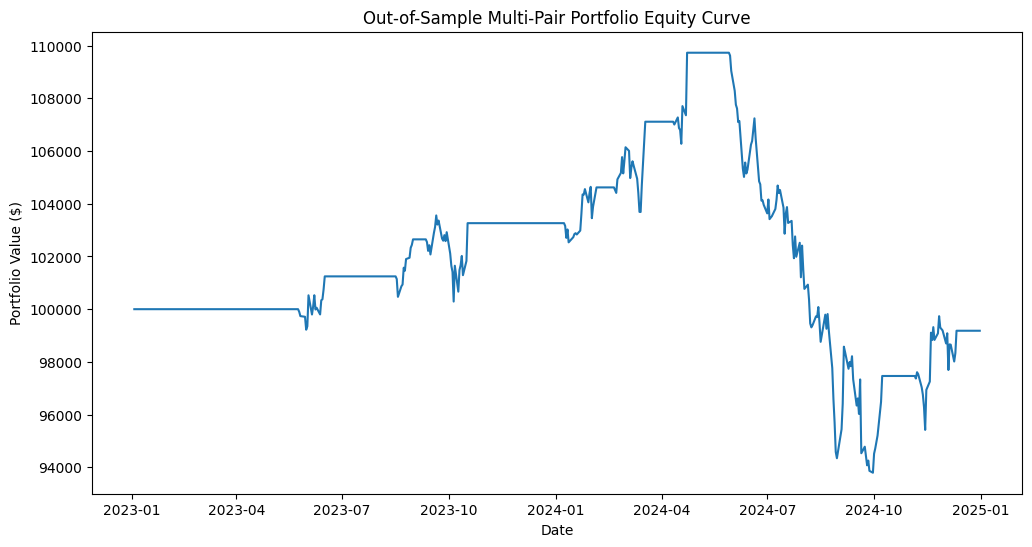

Total Return: -0.82%
Win Rate: 21.12%
Annualized Volatility: 7.25%
Sharpe Ratio: -0.02
Max Drawdown: -14.52%


In [ ]:
def compute_metrics(returns, initial_capital=100_000):
    equity = initial_capital * (1 + returns).cumprod()
    total_return = equity.iloc[-1] / initial_capital - 1
    win_rate = (returns > 0).mean()
    volatility = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else np.nan
    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()
    return {
        "Total Return": f"{total_return:.2%}",
        "Win Rate": f"{win_rate:.2%}",
        "Annualized Volatility": f"{volatility:.2%}",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Max Drawdown": f"{max_drawdown:.2%}",
    }, equity

metrics, portfolio_equity = compute_metrics(portfolio_returns)

plt.figure(figsize=(12, 6))
plt.plot(portfolio_equity)
plt.title("Out-of-Sample Multi-Pair Portfolio Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.show()

for k, v in metrics.items():
    print(f"{k}: {v}")


## Results & Interpretation

Of 8 economically-motivated candidate pairs, 1 (**KO-PEP**, corrected
p = 0.036) survived cointegration testing after Benjamini-Hochberg FDR
correction. Trading that pair out-of-sample with a fixed z-score threshold
strategy produced:

| Metric | Value |
|---|---|
| Total Return | -0.82% |
| Win Rate | 21.12% |
| Annualized Volatility | 7.25% |
| Sharpe Ratio | -0.02 |
| Max Drawdown | -14.52% |

**What this does show:** the pipeline is leak-free end-to-end. train/test
separation, no future information in pair selection or hedge ratio fitting,
and multiple-testing correction that isn't loosened to force a result. KO
and PEP show a statistically defensible long-run relationship even after
correction.

**What this does not show:** that pairs trading is profitable, or even that
KO-PEP is tradeable in practice. A naive fixed-threshold strategy on a
single pair lost money out-of-sample. With n=1, no conclusion about the
broader strategy family is justified either way - this result says the
methodology is sound, not that the strategy works. The gap between
"statistically cointegrated" and "profitably tradeable" is exactly the kind
of gap a fixed-rule strategy is bad at closing, which motivates the planned
ML-based signal filtering layer (Phase 7) and a larger, more diverse
candidate universe as the immediate next steps.

# Phase 7 - Known Limitations 

- **Hedge ratio is static, not walk-forward.** Beta is estimated once on
  train and held fixed through the entire test window. A production system
  would re-estimate it on a rolling basis. This is a stated next step, not
  a built feature.
- **No momentum module.** Was listed as a goal in an earlier version, never
  implemented. Removed from scope here.
- **No live dashboard.** No Streamlit or other UI exists in this repo.
- **Flat transaction cost assumption.** 10 bps per trade, no modeling of
  slippage that scales with trade size or market volatility.
- **Single train/test split, not walk-forward validation.** A more rigorous
  version would roll the train/test windows forward through time and check
  that pair selection stays stable across multiple splits, not just one.
- **Single surviving pair (n=1).** Only KO-PEP survived FDR-corrected
  cointegration testing out of 8 candidates. A sample of one pair is not
  enough to draw conclusions about pairs trading as a strategy family in
  this universe — it means this specific screen found one defensible
  relationship, nothing broader.
- **Entry/exit thresholds are untuned.** Z-score entry (2.0) and exit (0.5)
  were chosen as reasonable defaults, not calibrated against a held-out
  validation period. Tuning them on the test window would reintroduce the
  exact look-ahead bias this notebook was built to eliminate.
